## 1. ⚡ NumPy Arrays vs Python Lists

**What you'll learn, in order:**
1. ⚡ NumPy Arrays vs Python Lists (Speed & Memory)
2. 🎯 Advanced Indexing
3. 📡 Broadcasting *(+ 3.1 Broadcasting Rules)*
4. 🧮 Working with Mathematical Formulas
5. 🕳️ Working with Missing Values
6. 📉 Plotting Graphs
7. 🌐 Meshgrids

> **In short:** this notebook goes beyond the basics — it shows *why* NumPy is fast, and how to use indexing, broadcasting, and vectorized math the way real ML/data code does.

In [1]:
# speed
# list
a = [i for i in range(10000000)]
b = [i for i in range(10000000,20000000)]

c_python = []
import time

start = time.time()
for i in range(len(a)):
  c_python.append(a[i] + b[i])
end_python = time.time()-start
print(end_python)

0.8158421516418457


This times a plain Python `for` loop adding two 10-million-element lists, one number at a time — no shortcuts, pure Python.

In [2]:
# numpy
import numpy as np
a = np.arange(10000000)
b = np.arange(10000000,20000000)

start = time.time()
c_numpy = a + b
end_numpy = time.time()-start
print(end_numpy)

0.005137920379638672


Same job, but as one vectorized NumPy operation (`a + b`) — no explicit loop written. The loop still happens, just inside fast, pre-compiled C code instead of Python.

In [3]:
end_python/end_numpy # how much faster is numpy

158.78839907192577

This ratio is usually 20-100x+ in NumPy's favor, and the gap grows as the array gets bigger — vectorization pays off most on large data.

In [4]:
# memory
a = [i for i in range(10000000)]
import sys

sys.getsizeof(a)

89095160

In [5]:
a = np.arange(10000000,dtype=np.int8)
sys.getsizeof(a)

10000112

In [6]:
type(a)

numpy.ndarray

**Why the memory gap?** A Python list stores *pointers* to full Python int objects (each with its own overhead); a NumPy array stores raw bytes back-to-back, all sharing one dtype. Forcing a small dtype like `int8` (1 byte/element) shrinks memory further — but only works if your numbers actually fit that range (-128 to 127).

**Bonus: vectorized dot product vs a Python loop:**

In [7]:
import time

a = list(range(1000000))
b = list(range(1000000, 2000000))

start = time.time()
dot_python = sum(x*y for x, y in zip(a, b))
print("python:", time.time() - start)

python: 0.03448796272277832


In [8]:
a_np = np.arange(1000000)
b_np = np.arange(1000000, 2000000)

start = time.time()
dot_numpy = np.dot(a_np, b_np)
print("numpy:", time.time() - start)

print(dot_python == dot_numpy)   # same answer, very different speed

numpy: 0.0003829002380371094
True


## 2. 🎯 Advanced Indexing

Beyond basic slicing (covered in the intro notebook), NumPy supports two more ways to select data: **fancy indexing** (pick using a list of positions) and **boolean indexing** (pick using a True/False condition). Both return a *copy*, not a view.

In [9]:
# Normal Indexing and slicing

a = np.arange(24).reshape(6,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [10]:
a[1,2].item()

6

In [11]:
a[1:3,1:3]

array([[ 5,  6],
       [ 9, 10]])

In [12]:
# Fancy Indexing rows print
a[[0,2,3,5]]

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [20, 21, 22, 23]])

In [13]:
# Fancy Indexing column print
a[:,[0, 2, 3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

In [14]:
# Fancy Indexing

a[:,[0,2,3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

Cells above (`a[:,[0,2,3]]`) repeat the same fancy-indexing idea twice while experimenting — both correct, just duplicated.

In [15]:
# Boolean Indexing
a = np.random.randint(1,100,24).reshape(6,4)
a

array([[14, 67, 14, 30],
       [65, 13, 17, 74],
       [ 6, 10, 66, 65],
       [26, 86, 85,  5],
       [41, 29, 62, 32],
       [11, 84, 72, 61]])

Boolean indexing: build a mask by comparing the whole array at once, then use that mask inside `[]` to keep only the matching elements.

In [16]:
# find all numbers greater than 50
a[a > 50]

array([67, 65, 74, 66, 65, 86, 85, 62, 84, 72, 61])

In [17]:
# find out even numbers
a[a % 2 == 0]

array([14, 14, 30, 74,  6, 10, 66, 26, 86, 62, 32, 84, 72])

In [18]:
# find all numbers greater than 50 and are even

a[(a > 50) & (a % 2 == 0)]

array([74, 66, 86, 62, 84, 72])

In [19]:
# find all numbers not divisible by 7
a[~(a % 7 == 0)]

array([67, 30, 65, 13, 17, 74,  6, 10, 66, 65, 26, 86, 85,  5, 41, 29, 62,
       32, 11, 72, 61])

**Gotcha:** combine conditions with `&`, `|`, `~` — not Python's `and`/`or`/`not` — and wrap each condition in parentheses. NumPy needs these so the comparison happens *element-wise* instead of trying to collapse the whole array into one True/False value.

**Combining fancy + boolean indexing, and finding positions with `np.where`:**

In [20]:
a = np.random.randint(1, 100, 24).reshape(6, 4)

# fancy indexing: pick specific rows, THEN apply a boolean filter on the result
subset = a[[0, 2, 4]]              # rows 0, 2, 4
print(subset[subset > 50])         # then filter within just those rows

[87 64 91 99 78 60 96]


In [21]:
# np.where gives you the (row, col) positions of matches, not just the values
rows, cols = np.where(a > 50)
print(list(zip(rows, cols))[:5])   # first 5 (row, col) positions where a > 50

[(np.int64(0), np.int64(3)), (np.int64(1), np.int64(0)), (np.int64(2), np.int64(1)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(0))]


## 3. 📡 Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.

In [22]:
# same shape
a = np.arange(6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


In [23]:
# diff shape
a = np.arange(6).reshape(2,3)
b = np.arange(3).reshape(1,3)

print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]
[[0 2 4]
 [3 5 7]]


Here `b` (shape (1,3)) is stretched to match `a` (shape (2,3)) — broadcasting rule 2 in action.

### 3.1 📏 Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

<img src = "https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png">

The picture: the smaller array (the darker strip) is virtually repeated to match the bigger one, without NumPy actually copying that data in memory.

In [24]:
# More examples

a = np.arange(12).reshape(4,3)
b = np.arange(3)

print(a)
print(b)

print(a+b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [25]:
a = np.arange(12).reshape(3,4)
b = np.arange(4)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2 3]
[[ 0  2  4  6]
 [ 4  6  8 10]
 [ 8 10 12 14]]


In [26]:
a = np.arange(3).reshape(1,3)
b = np.arange(3).reshape(3,1)

print(a)
print(b)

print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [27]:
a = np.arange(3).reshape(1,3)
b = np.arange(4).reshape(4,1)

print(a)
print(b)

print(a + b)

[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [28]:
a = np.array([1])
# shape -> (1,1)
b = np.arange(4).reshape(2,2)
# shape -> (2,2)

print(a)
print(b)

print(a+b)

[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


Even a single-element array broadcasts against any shape — it gets stretched in every dimension.

In [29]:
a = np.arange(12).reshape(3,4)
b = np.arange(12).reshape(4,3)

print(a)
print(b)

# print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


**This one fails.** Shapes (3,4) and (4,3) share no dimension of size 1 and don't already match, so NumPy raises `ValueError: operands could not be broadcast together`. Broadcasting is not matrix multiplication — shapes must genuinely line up.

In [30]:
a = np.arange(16).reshape(4,4)
b = np.arange(4).reshape(2,2)

print(a)
print(b)

# print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


**Fails too, same reason:** (4,4) vs (2,2) — no dimension is 1, and 4 ≠ 2. When you hit this error in real code, the first debugging step is always to print `.shape` on both arrays.

**A real use case — normalizing data with broadcasting:**

In [31]:
# subtract the column mean from every row (mean-centering, a common preprocessing step)
data = np.arange(12).reshape(4, 3).astype(float)
col_means = data.mean(axis=0)        # shape (3,)

print(data)
print(col_means)
print(data - col_means)              # (4,3) - (3,) broadcasts col_means across every row

[[ 0.  1.  2.]
 [ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]]
[4.5 5.5 6.5]
[[-4.5 -4.5 -4.5]
 [-1.5 -1.5 -1.5]
 [ 1.5  1.5  1.5]
 [ 4.5  4.5  4.5]]


In [32]:
# scale each ROW by a different factor using a column vector
scale = np.array([1, 10, 100, 1000]).reshape(4, 1)   # shape (4,1)
print(data * scale)     # (4,3) * (4,1) -> row i is multiplied by scale[i]

[[0.0e+00 1.0e+00 2.0e+00]
 [3.0e+01 4.0e+01 5.0e+01]
 [6.0e+02 7.0e+02 8.0e+02]
 [9.0e+03 1.0e+04 1.1e+04]]


## 4. 🧮 Working with Mathematical Formulas

NumPy math functions apply to every element at once — the same formulas you'd otherwise write with a summation or loop in plain Python, just shorter and much faster. These specific ones show up constantly in machine learning.

In [33]:
a = np.arange(10)
np.sin(a)

array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

In [34]:
# sigmoid
def sigmoid(array):
  return 1/(1 + np.exp(-(array)))


a = np.arange(10)

sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

**Sigmoid** squashes any real number into the range (0, 1) — the classic activation function in logistic regression and neural-network output layers.

In [35]:
# mean squared error

actual = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

In [36]:
actual

array([36, 36,  4, 31, 28,  7, 49,  6, 39,  8, 18, 24, 20, 48, 34, 39, 30,
       26, 49, 22, 35, 47, 30, 22,  9])

In [37]:
predicted

array([ 5, 42, 49, 25, 10, 11, 20, 22,  4, 21, 28, 17, 40, 15, 32,  2, 43,
        9,  8, 14,  7,  4, 14, 49,  9])

In [38]:
# NOTE: mislabeled -- this is still MSE, not real categorical cross-entropy (see the full CCE section at the end of this topic)
np.mean((actual - predicted)**2)

np.float64(588.84)

**Heads up — mislabeled above:** the cell above said "categorical cross entropy" but its formula is just MSE again. Real CCE is a *multi-class* loss — it needs a one-hot actual vector and a probability distribution (like softmax output) as the prediction, not arbitrary integers. See the full explanation and worked example at the end of this section.

In [39]:
## Function to calculate the MSE
def mse(actual,predicted):
  return np.mean((actual - predicted)**2)

mse(actual,predicted)

np.float64(588.84)

**MSE (Mean Squared Error)** — the average of the squared differences between predicted and actual values. Squaring punishes big mistakes more than small ones, and makes every term positive so they don't cancel out.

**More MSE examples — why squaring matters:**

In [40]:
perfect_actual = np.array([10, 20, 30, 40])
perfect_pred = np.array([10, 20, 30, 40])
print(mse(perfect_actual, perfect_pred))   # 0 -- a perfect prediction has zero error

0.0


In [41]:
# MSE punishes big misses much harder than small ones -- compare it to MAE (mean absolute error)
y_true = np.array([10, 10, 10, 10])
y_pred_small_errors = np.array([12, 8, 11, 9])     # off by 1-2 each time
y_pred_one_outlier  = np.array([10, 10, 10, 20])   # spot on, except one big miss

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

print("small, spread-out errors -> MSE:", mse(y_true, y_pred_small_errors), " MAE:", mae(y_true, y_pred_small_errors))
print("one big outlier          -> MSE:", mse(y_true, y_pred_one_outlier),  " MAE:", mae(y_true, y_pred_one_outlier))

small, spread-out errors -> MSE: 2.5  MAE: 1.5
one big outlier          -> MSE: 25.0  MAE: 2.5


In [42]:
# NOTE: mislabeled -- this is still MSE, not real BCE (see the corrected version below)
np.mean((actual - predicted)**2).item()

588.84

**Heads up — mislabeled above:** the cell above said "binary cross entropy" but its formula (`mean((actual-predicted)**2)`) is just MSE again. Real BCE needs *probabilities* (values between 0 and 1), not arbitrary integers like `actual`/`predicted` here. Here's what true BCE looks like:

### 4.3 🎯 Binary Cross-Entropy (BCE)
Used for **binary** classification (exactly two outcomes, e.g. spam vs. not-spam, sick vs. healthy). The true label is `0` or `1`, and the prediction is a **probability** between 0 and 1 (e.g. straight out of `sigmoid`).

Formula: `BCE = -mean(actual * log(predicted) + (1 - actual) * log(1 - predicted))` — for each sample only one of the two terms survives (whichever matches the true label), and that term grows sharply the further the predicted probability drifts from the truth.

In [43]:
# real binary cross-entropy needs probabilities in (0, 1), not raw integers
actual_bin = np.random.randint(0, 2, 10)     # true labels: 0 or 1
predicted_prob = np.random.random(10)        # predicted probabilities

def binary_cross_entropy(actual, predicted, eps=1e-15):
    predicted = np.clip(predicted, eps, 1 - eps)  # avoid log(0)
    return -np.mean(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))

binary_cross_entropy(actual_bin, predicted_prob)

np.float64(0.5064049774060279)

**More BCE examples — low loss vs high loss:**

In [44]:
y_true = np.array([1, 0, 1, 0])
y_pred_good = np.array([0.95, 0.05, 0.90, 0.10])   # confident AND correct

print(binary_cross_entropy(y_true, y_pred_good))   # small loss

0.07832690502268844


In [45]:
y_pred_bad = np.array([0.05, 0.95, 0.10, 0.90])    # confident AND wrong

print(binary_cross_entropy(y_true, y_pred_bad))    # much bigger loss

2.6491586832740177


In [46]:
# per-sample loss -- see exactly which predictions are hurting the average
per_sample_loss = -(y_true * np.log(y_pred_bad) + (1 - y_true) * np.log(1 - y_pred_bad))
for yt, yp, loss in zip(y_true, y_pred_bad, per_sample_loss):
    print(f"true={yt}  pred={yp:.2f}  loss={loss:.3f}")

true=1  pred=0.05  loss=2.996
true=0  pred=0.95  loss=2.996
true=1  pred=0.10  loss=2.303
true=0  pred=0.90  loss=2.303


In [47]:
actual

array([36, 36,  4, 31, 28,  7, 49,  6, 39,  8, 18, 24, 20, 48, 34, 39, 30,
       26, 49, 22, 35, 47, 30, 22,  9])

**Softmax and vector norms — two more ML staples:**

In [48]:
def softmax(x):
    exps = np.exp(x - np.max(x))   # subtract max for numerical stability
    return exps / np.sum(exps)

scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)
print(probs, probs.sum())   # turns scores into probabilities that add up to 1

[0.65900114 0.24243297 0.09856589] 1.0


In [49]:
# vector norm (magnitude / length) -- used to measure error size, regularization, etc.
v = np.array([3, 4])
print(np.linalg.norm(v))          # sqrt(3^2 + 4^2) = 5.0
print(np.sqrt(np.sum(v**2)))      # same thing, computed manually

5.0
5.0


### 4.4 🔢 Categorical Cross-Entropy (CCE)
Used for **multi-class** classification (more than 2 categories) — the multi-class version of binary cross-entropy. The true label is a **one-hot vector** (1 for the correct class, 0 for every other class), and the prediction is a full probability distribution over all classes (e.g. straight out of `softmax`).

Formula: `CCE = -sum(actual_i * log(predicted_i))` across all classes — since `actual_i` is 0 everywhere except the correct class, this collapses to just `-log(predicted_correct_class)`.

In [50]:
def categorical_cross_entropy(actual, predicted, eps=1e-15):
    predicted = np.clip(predicted, eps, 1 - eps)   # avoid log(0)
    return -np.sum(actual * np.log(predicted))

# true class is index 2 (out of 4 possible classes) -> one-hot vector
true_class = np.array([0, 0, 1, 0])

# a confident, correct prediction (from softmax, so it already sums to 1)
confident_correct = softmax(np.array([0.5, 0.5, 5.0, 0.5]))
print(confident_correct)
print(categorical_cross_entropy(true_class, confident_correct))   # small loss

[0.01075071 0.01075071 0.96774788 0.01075071]
0.03278368372162418


In [51]:
# confident but WRONG prediction -- high confidence placed on the wrong class (index 0)
confident_wrong = softmax(np.array([5.0, 0.5, 0.5, 0.5]))
print(confident_wrong)
print(categorical_cross_entropy(true_class, confident_wrong))   # much bigger loss

[0.96774788 0.01075071 0.01075071 0.01075071]
4.532783683721624


## 5. 🕳️ Working with Missing Values

`np.nan` represents a missing/undefined number, and it behaves unlike anything else in Python: `np.nan == np.nan` is `False`, and any arithmetic touching a NaN produces another NaN — that's why you can't filter it out with plain `==`.

In [52]:
# Working with missing values -> np.nan
a = np.array([1,2,3,4,np.nan,6])
a

array([ 1.,  2.,  3.,  4., nan,  6.])

In [53]:
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

`np.isnan(a)` is the correct way to detect NaNs; `~` flips that mask to keep everything that is *not* NaN.

**Handling NaNs without dropping them:**

In [54]:
a = np.array([1, 2, np.nan, 4, np.nan, 6])

print(np.mean(a))       # nan -- one bad value poisons the whole result
print(np.nanmean(a))    # ignores NaNs when computing the mean

nan
3.25


In [55]:
print(np.nan_to_num(a, nan=0))   # replace every NaN with a chosen value (here, 0)

[1. 2. 0. 4. 0. 6.]


## 6. 📉 Plotting Graphs

NumPy generates the x-values (`np.linspace`), you compute `y = f(x)` with a NumPy formula, and matplotlib draws the line — this same pattern works for literally any function.

In [63]:
# !pip install matplotlib

import matplotlib.pyplot as plt

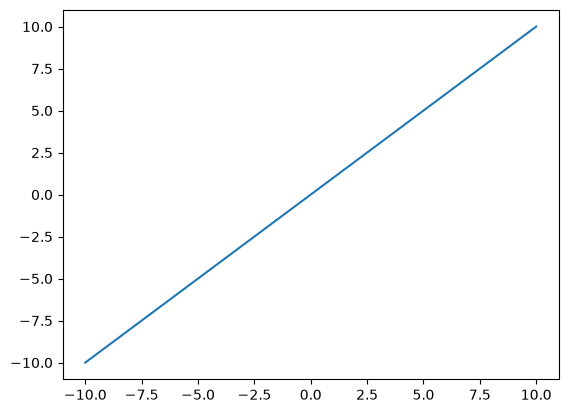

In [64]:
# plotting a 2D plot
# x = y


x = np.linspace(-10,10,100)
y = x

plt.plot(x,y)

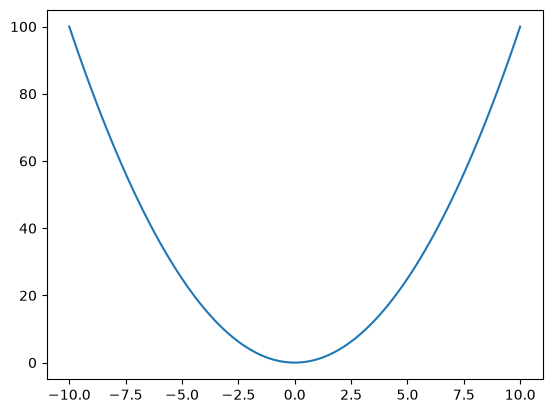

In [65]:
# y = x^2
x = np.linspace(-10,10,100)
y = x**2

plt.plot(x,y)

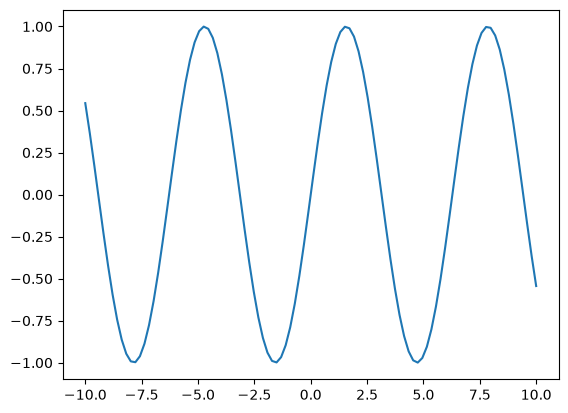

In [66]:
# y = sin(x)
x = np.linspace(-10,10,100)
y = np.sin(x)

plt.plot(x,y)

/var/folders/9l/7fyd43ns7bq1fck6zqsh8qs40000gn/T/ipykernel_84222/2564014901.py:3: RuntimeWarning: invalid value encountered in log
  y = x * np.log(x)


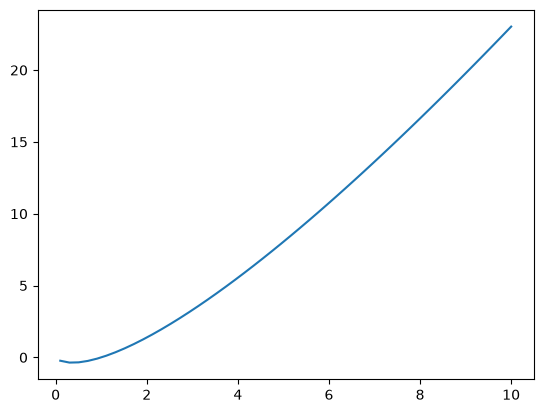

In [68]:
# y = xlog(x)
x = np.linspace(-10,10,100)
y = x * np.log(x)

plt.plot(x,y)

**Gotcha:** `np.log(x)` is undefined for `x <= 0`, and half of this range is negative — those points come out as `nan` (with a runtime warning) and simply won't show on the plot. In real code, restrict the domain first, e.g. `x = np.linspace(0.01, 10, 100)`.

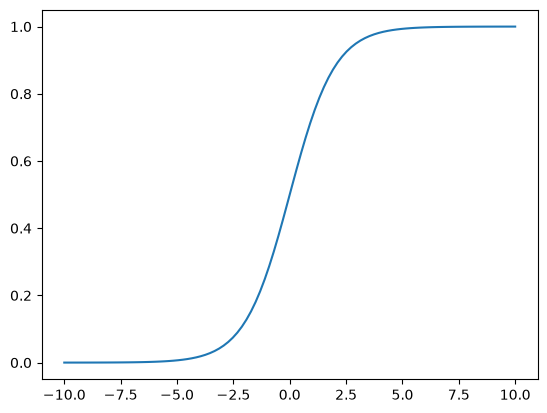

In [69]:
# sigmoid
x = np.linspace(-10,10,100)
y = 1/(1+np.exp(-x))

plt.plot(x,y)

**Multiple lines with a legend, and a scatter plot:**

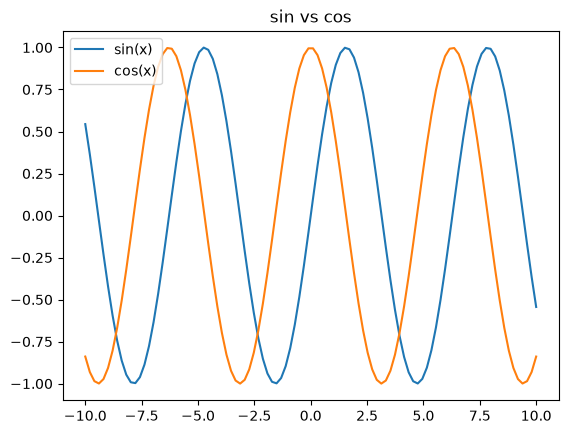

In [70]:
x = np.linspace(-10, 10, 100)

plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.legend()
plt.title("sin vs cos")
plt.show()

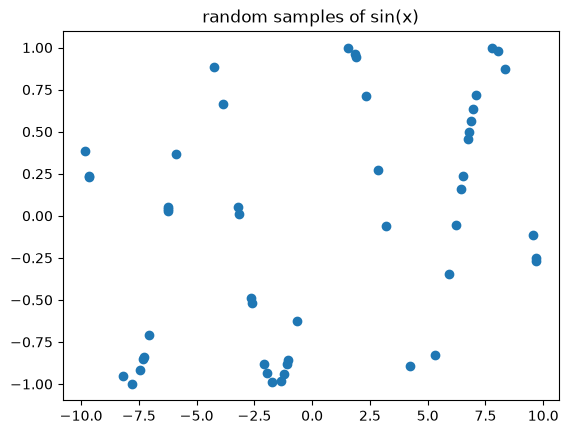

In [71]:
# scatter plot: good for showing individual points instead of a continuous line
x_sample = np.random.uniform(-10, 10, 50)
y_sample = np.sin(x_sample)

plt.scatter(x_sample, y_sample)
plt.title("random samples of sin(x)")
plt.show()

## 7. 🌐 Meshgrids

A **meshgrid** turns two 1D arrays (x-values and y-values) into two 2D grids, so you can evaluate a function like `z = f(x, y)` at *every combination* of x and y at once — the setup behind contour plots, heatmaps, and 3D surfaces.

In [72]:
# Meshgrids
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)

xx, yy = np.meshgrid(x, y)
print(xx.shape, yy.shape)   # both (50, 50) -- every combination of x and y

(50, 50) (50, 50)


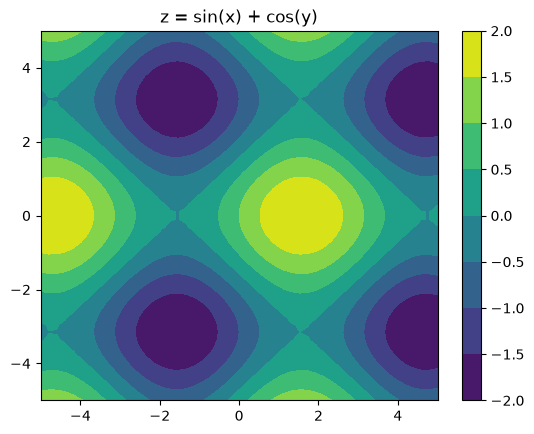

In [73]:
# use the grid to evaluate a function at every (x, y) point, then visualize it
z = np.sin(xx) + np.cos(yy)

plt.contourf(xx, yy, z, cmap='viridis')
plt.colorbar()
plt.title('z = sin(x) + cos(y)')
plt.show()

**A practical use — a radial distance grid, and a 3D surface:**

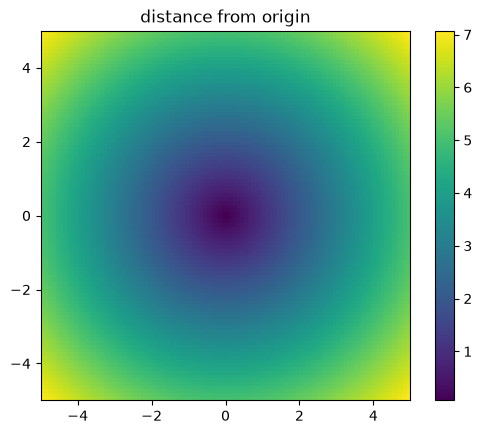

In [74]:
# distance of every (x, y) point from the origin -- the basis of radial gradients/filters
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
xx, yy = np.meshgrid(x, y)

distance = np.sqrt(xx**2 + yy**2)
plt.imshow(distance, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("distance from origin")
plt.show()

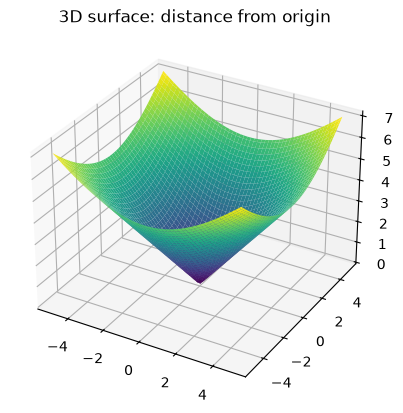

In [75]:
# the same grid, now as an actual 3D surface
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx, yy, distance, cmap='viridis')
plt.title("3D surface: distance from origin")
plt.show()

## 8. ✅ Key Takeaways
- Vectorized NumPy ops beat Python loops by 20-100x+ because the looping happens in compiled C, not Python.
- Smaller dtypes (e.g. `int8` vs default `int64`) cut memory use — but only fit a smaller range of numbers.
- Fancy indexing (`a[[list]]`) and boolean indexing (`a[mask]`) both return copies; combine boolean conditions with `&` `|` `~`, not `and`/`or`/`not`.
- Broadcasting stretches a smaller array to match a bigger one, but only when shapes already match or one side has size 1 — otherwise it raises `ValueError`.
- Vectorized math (`sigmoid`, `mse`, etc.) is just the formula applied to every element at once — watch for domain gotchas like `log(x)` needing `x > 0`.
- `np.nan` never equals itself — always test for it with `np.isnan()`, never `==`.
- `np.meshgrid` builds the (x, y) grid needed to evaluate and plot a function of two variables.